In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:/Users/Jumbo/OneDrive/Desktop/stores_sales_forecasting.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [4]:
df.shape

(2121, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [8]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2116    False
2117    False
2118    False
2119    False
2120    False
Length: 2121, dtype: bool

In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [11]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [12]:
df.drop(columns=['Row ID','Order ID','Ship Date','Ship Mode','Customer ID','Customer Name','Segment','Postal Code','Region','Product ID'],inplace=True)

In [13]:
df['Sales']=df['Sales'].round(2)
df['Profit']=df['Profit'].round(2)

In [14]:
df.head()

,Order Date,Country,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2016-11-08,United States,Henderson,Kentucky,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2016-11-08,United States,Henderson,Kentucky,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,2015-10-11,United States,Fort Lauderdale,Florida,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
3,2014-06-09,United States,Los Angeles,California,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.17
4,2014-06-09,United States,Los Angeles,California,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.18,9,0.20,85.31


In [15]:
pd.set_option('display.max_columns',None)
df.describe(include='all').round(2)

,Order Date,Country,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,2121,2121,2121,2121,2121,2121,2121,2121.00,2121.00,2121.00,2121.00
unique,NaN,1,371,48,1,4,380,NaN,NaN,NaN,NaN
top,NaN,United States,New York City,California,Furniture,Furnishings,KI Adjustable-Height Table,NaN,NaN,NaN,NaN
freq,NaN,2121,192,444,2121,957,18,NaN,NaN,NaN,NaN
mean,2016-04-30 03:54:13.748231680,NaN,NaN,NaN,NaN,NaN,NaN,349.83,3.79,0.17,8.70
min,2014-01-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.89,1.00,0.00,-1862.31
25%,2015-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,47.04,2.00,0.00,-12.85
50%,2016-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,182.22,3.00,0.20,7.77
75%,2017-05-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,435.17,5.00,0.30,33.73
max,2017-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4416.17,14.00,0.70,1013.13


high value outliers are present in the sales column since mean value > median value.

EDA and Data Preprocessing

In [16]:
#inconsistent capitalization 
text_cols = ['Country','City','State','Category','Sub-Category','Product Name']
for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [17]:
df.dtypes

Order Date      datetime64[ns]
Country                 object
City                    object
State                   object
Category                object
Sub-Category            object
Product Name            object
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object

In [18]:
df.head()

,Order Date,Country,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2016-11-08,united states,henderson,kentucky,furniture,bookcases,bush somerset collection bookcase,261.96,2,0.00,41.91
1,2016-11-08,united states,henderson,kentucky,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,...",731.94,3,0.00,219.58
2,2015-10-11,united states,fort lauderdale,florida,furniture,tables,bretford cr4500 series slim rectangular table,957.58,5,0.45,-383.03
3,2014-06-09,united states,los angeles,california,furniture,furnishings,eldon expressions wood and plastic desk access...,48.86,7,0.00,14.17
4,2014-06-09,united states,los angeles,california,furniture,tables,chromcraft rectangular conference tables,1706.18,9,0.20,85.31


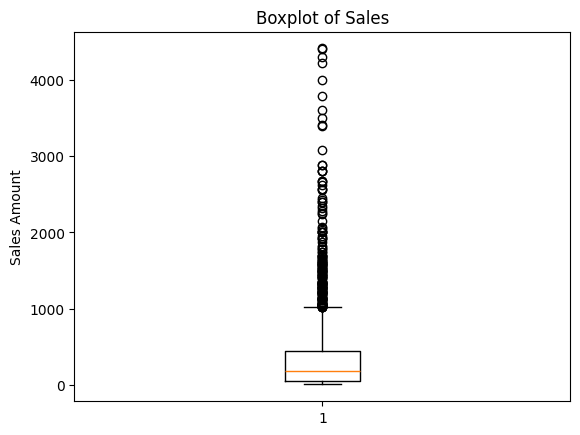

In [19]:
#visualizing outliers
plt.boxplot(df['Sales'])
plt.title("Boxplot of Sales")
plt.ylabel("Sales Amount")
plt.show()


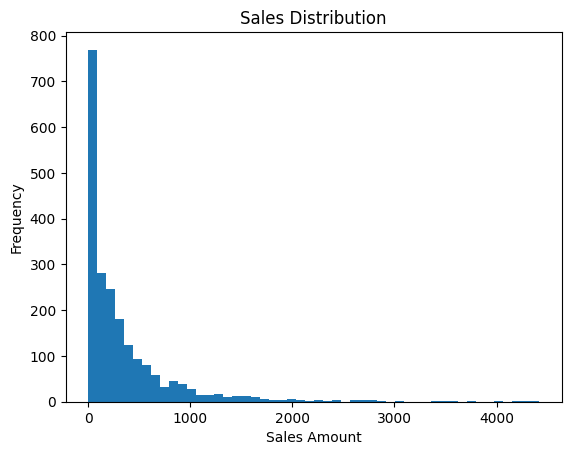

In [20]:
#histogram of sales(shows skewness)
plt.hist(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()


In [21]:
#statistical detection of outliers
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print("Outlier count =", len(outliers))
print("Upper bound =", upper_bound)
print("Max sale =", df['Sales'].max())


Outlier count = 164
Upper bound = 1017.365
Max sale = 4416.17


In [22]:
#handling outliers
df['Sales_capped'] = df['Sales'].clip(lower=lower_bound, upper=upper_bound)


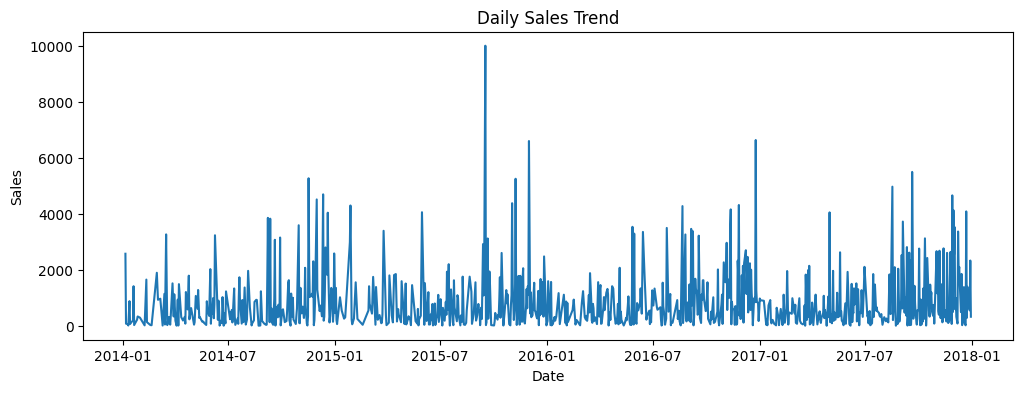

In [23]:
#visualize sales trends
#daily sales trend
df=df.sort_values('Order Date')
daily_sales = df.groupby('Order Date')['Sales'].sum()
plt.figure(figsize=(12,4))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()



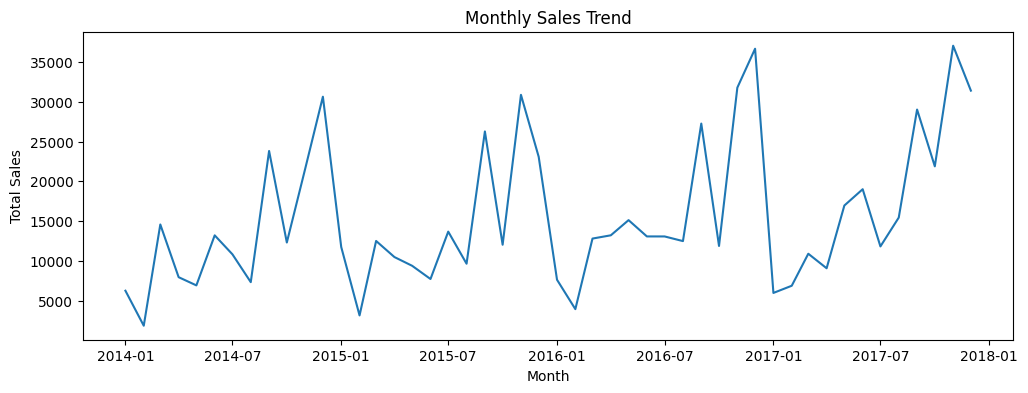

In [24]:
#monthly sales trend
df['YearMonth']=df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,4))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


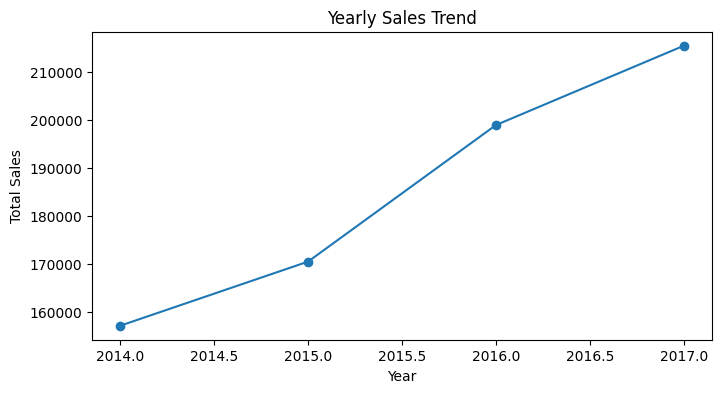

In [25]:
#yearly sales trend
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.figure(figsize=(8,4))
plt.plot(yearly_sales, marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()


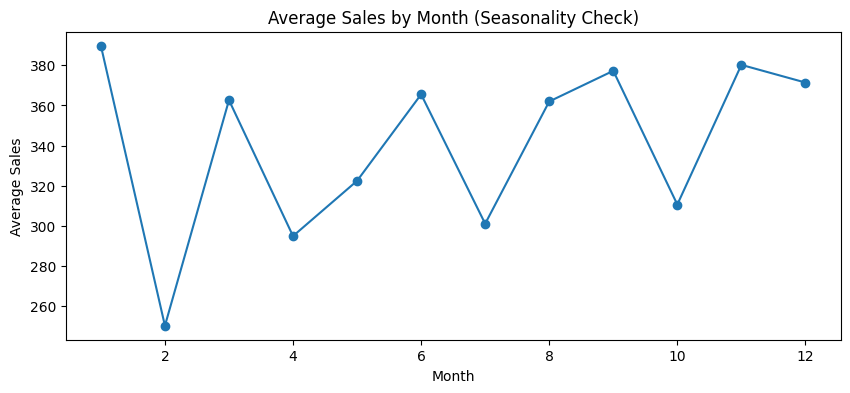

In [26]:
#average sales by month
df['Month'] = df['Order Date'].dt.month
monthly_avg = df.groupby('Month')['Sales'].mean()
plt.figure(figsize=(10,4))
plt.plot(monthly_avg, marker='o')
plt.title("Average Sales by Month (Seasonality Check)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


In [27]:
print("Highest Sales Month:", monthly_sales.idxmax(), "=", monthly_sales.max())
print("Lowest Sales Month:", monthly_sales.idxmin(), "=", monthly_sales.min())


Highest Sales Month: 2017-11-01 00:00:00 = 37056.72
Lowest Sales Month: 2014-02-01 00:00:00 = 1839.66


In [28]:
#correlation between numeric variables
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
print(corr)


             Sales  Quantity  Discount    Profit
Sales     1.000000  0.437464 -0.028576  0.173510
Quantity  0.437464  1.000000 -0.015695  0.061213
Discount -0.028576 -0.015695  1.000000 -0.483769
Profit    0.173510  0.061213 -0.483769  1.000000


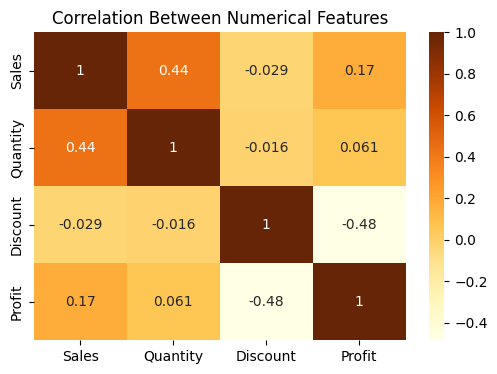

In [29]:
#correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='YlOrBr')
plt.title("Correlation Between Numerical Features")
plt.show()


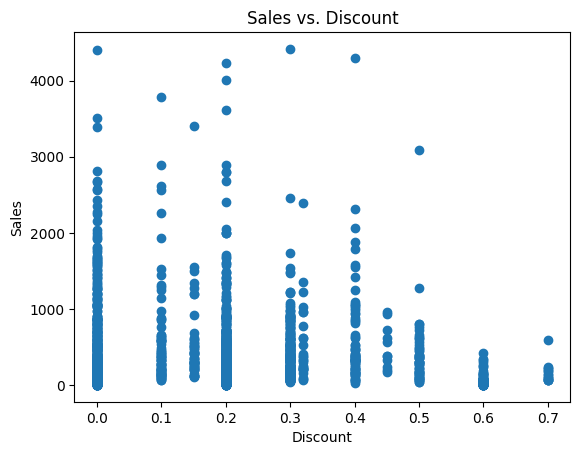

In [30]:
#sales vs discount
plt.scatter(df['Discount'], df['Sales'])
plt.title("Sales vs. Discount")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.show()


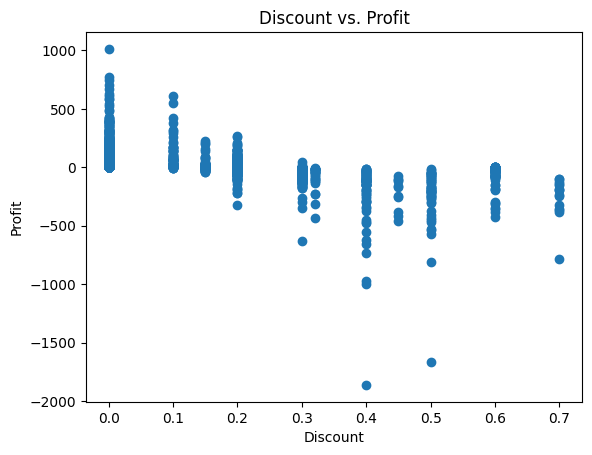

In [31]:
#discount vs profit
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs. Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


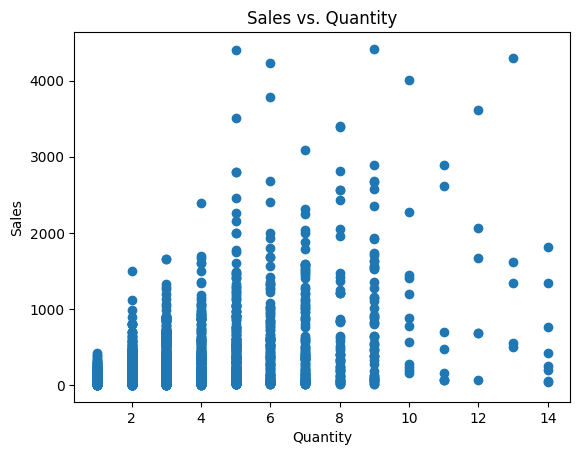

In [32]:
#sales vs quantity
plt.scatter(df['Quantity'], df['Sales'])
plt.title("Sales vs. Quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()


In [33]:
#feature engineering
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfWeek'] = df['Order Date'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)


In [34]:
#holiday indicators
us_holidays = pd.to_datetime([
    '2014-11-28','2015-11-27','2016-11-25','2017-11-24',  # Black Friday
    '2014-12-25','2015-12-25','2016-12-25','2017-12-25',  # Christmas
    '2014-07-04','2015-07-04','2016-07-04','2017-07-04',  # Independence Day
    '2014-01-01','2015-01-01','2016-01-01','2017-01-01'   # New Year
])

df['IsHoliday'] = df['Order Date'].isin(us_holidays).astype(int)


In [35]:
df.head()

,Order Date,Country,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Sales_capped,YearMonth,Year,Month,Day,Quarter,DayOfWeek,IsWeekend,IsHoliday
1577,2014-01-06,united states,henderson,kentucky,furniture,chairs,global deluxe high-back manager's chair,2573.82,9,0.0,746.41,1017.365,2014-01,2014,1,6,1,0,0,0
1626,2014-01-07,united states,huntsville,texas,furniture,furnishings,"howard miller 14-1/2"" diameter chrome round wa...",76.73,3,0.6,-53.71,76.730,2014-01,2014,1,7,1,1,0,0
181,2014-01-10,united states,springfield,virginia,furniture,furnishings,"howard miller 11-1/2"" diameter ridgewood wall ...",51.94,1,0.0,21.30,51.940,2014-01,2014,1,10,1,4,0,0
150,2014-01-11,united states,dover,delaware,furniture,furnishings,"dax value u-channel document frames, easel back",9.94,2,0.0,3.08,9.940,2014-01,2014,1,11,1,5,1,0
631,2014-01-13,united states,mount pleasant,south carolina,furniture,chairs,global highback leather tilter in burgundy,545.94,6,0.0,87.35,545.940,2014-01,2014,1,13,1,0,0,0


In [36]:
#generate lag features
df['YearMonth'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
monthly_sales = df.groupby('YearMonth')['Sales'].sum().to_frame()


In [37]:
#lag 1,2,3 months
monthly_sales['Lag_1'] = monthly_sales['Sales'].shift(1)
monthly_sales['Lag_2'] = monthly_sales['Sales'].shift(2)
monthly_sales['Lag_3'] = monthly_sales['Sales'].shift(3)

In [38]:
#create rolling (moving) averages
monthly_sales['Rolling_3'] = monthly_sales['Sales'].rolling(window=3).mean() #3 month rolling average
monthly_sales['Rolling_6'] = monthly_sales['Sales'].rolling(window=6).mean() #6 month rolling average
monthly_sales['Rolling_12'] = monthly_sales['Sales'].rolling(window=12).mean() #12 month rolling average

In [39]:
#create rolling standard deviation
monthly_sales['Rolling_STD_3'] = monthly_sales['Sales'].rolling(window=3).std()
monthly_sales['Rolling_STD_6'] = monthly_sales['Sales'].rolling(window=6).std()


In [40]:
monthly_sales.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_6,Rolling_12,Rolling_STD_3,Rolling_STD_6
YearMonth,,,,,,,,,
2014-01-01,6242.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02-01,1839.66,6242.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-03-01,14573.98,1839.66,6242.53,NaN,7552.056667,NaN,NaN,6467.369754,NaN
2014-04-01,7944.83,14573.98,1839.66,6242.53,8119.490000,NaN,NaN,6368.956434,NaN
2014-05-01,6912.79,7944.83,14573.98,1839.66,9810.533333,NaN,NaN,4157.414431,NaN


In [41]:
monthly_model = monthly_sales.dropna()

In [42]:
monthly_model.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_3,Rolling_6,Rolling_12,Rolling_STD_3,Rolling_STD_6
YearMonth,,,,,,,,,
2014-12-01,30645.97,21564.85,12304.24,23816.48,21505.020000,17745.493333,13099.405000,9171.011371,8990.051752
2015-01-01,11739.93,30645.97,21564.85,12304.24,21316.916667,17898.636667,13557.521667,9455.458229,8855.321425
2015-02-01,3134.37,11739.93,30645.97,21564.85,15173.423333,17200.973333,13665.414167,14073.510258,9952.352529
2015-03-01,12499.79,3134.37,11739.93,30645.97,9124.696667,15314.858333,13492.565000,5201.668673,9510.396646
2015-04-01,10475.71,12499.79,3134.37,11739.93,8703.290000,15010.103333,13703.471667,4927.867433,9654.372088


In [43]:
#encoding categorical variables
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)


Index(['Country', 'City', 'State', 'Category', 'Sub-Category', 'Product Name'], dtype='object')


In [44]:
#one-hot encoding low-cardinality features
df = pd.get_dummies(df,columns=['Country', 'Category', 'Sub-Category'],drop_first=True)


In [45]:
#label encoding high-cardinality features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
high_card_cols = ['City', 'State', 'Product Name']
for col in high_card_cols:
    df[col] = le.fit_transform(df[col])


In [46]:
df.head()

,Order Date,City,State,Product Name,Sales,Quantity,Discount,Profit,Sales_capped,YearMonth,Year,Month,Day,Quarter,DayOfWeek,IsWeekend,IsHoliday,Sub-Category_chairs,Sub-Category_furnishings,Sub-Category_tables
1577,2014-01-06,137,15,175,2573.82,9,0.0,746.41,1017.365,2014-01-01,2014,1,6,1,0,0,0,True,False,False
1626,2014-01-07,147,40,252,76.73,3,0.6,-53.71,76.730,2014-01-01,2014,1,7,1,1,0,0,False,True,False
181,2014-01-10,323,43,245,51.94,1,0.0,21.30,51.940,2014-01-01,2014,1,10,1,4,0,0,False,True,False
150,2014-01-11,88,6,90,9.94,2,0.0,3.08,9.940,2014-01-01,2014,1,11,1,5,1,0,False,True,False
631,2014-01-13,223,37,187,545.94,6,0.0,87.35,545.940,2014-01-01,2014,1,13,1,0,0,0,True,False,False


In [47]:
df.drop(columns=['Product Name','YearMonth','Order Date'])

,City,State,Sales,Quantity,Discount,Profit,Sales_capped,Year,Month,Day,Quarter,DayOfWeek,IsWeekend,IsHoliday,Sub-Category_chairs,Sub-Category_furnishings,Sub-Category_tables
1577,137,15,2573.82,9,0.0,746.41,1017.365,2014,1,6,1,0,0,0,True,False,False
1626,147,40,76.73,3,0.6,-53.71,76.730,2014,1,7,1,1,0,0,False,True,False
181,323,43,51.94,1,0.0,21.30,51.940,2014,1,10,1,4,0,0,False,True,False
150,88,6,9.94,2,0.0,3.08,9.940,2014,1,11,1,5,1,0,False,True,False
631,223,37,545.94,6,0.0,87.35,545.940,2014,1,13,1,0,0,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,185,15,258.75,3,0.0,77.62,258.750,2017,12,29,4,4,0,0,True,False,False
1617,185,15,1207.84,8,0.0,314.04,1017.365,2017,12,29,4,4,0,0,True,False,False
1057,5,3,101.12,8,0.0,37.41,101.120,2017,12,29,4,4,0,0,False,True,False
1618,185,15,300.98,1,0.0,87.28,300.980,2017,12,29,4,4,0,0,True,False,False


Splitting data for training and testing

In [48]:
monthly_model=monthly_model.sort_index()

In [49]:
train_size = int(len(monthly_model)*0.8)
train = monthly_model.iloc[:train_size]
test = monthly_model.iloc[train_size:]

In [50]:
print("Train rows:",len(train))
print("Test rows:",len(test))

Train rows: 29
Test rows: 8


In [51]:
print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())


Train period: 2014-12-01 00:00:00 to 2017-04-01 00:00:00
Test period: 2017-05-01 00:00:00 to 2017-12-01 00:00:00


In [52]:
#training baseline model-Linear Regression
monthly_model=monthly_model.sort_index()
train_size=int(len(monthly_model)*0.8)
train=monthly_model.iloc[:train_size]
test=monthly_model.iloc[train_size:]


In [53]:
X_train = train[['Lag_1', 'Lag_2', 'Lag_3']]
y_train = train['Sales']
X_test = test[['Lag_1', 'Lag_2', 'Lag_3']]
y_test = test['Sales']


In [54]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
pred_lr = lr.predict(X_test)


In [56]:
#evaluate model performance
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
mape = mean_absolute_percentage_error(y_test, pred_lr)
print("Baseline Model: Linear Regression")
print("RMSE:", rmse)
print("MAPE:", mape)


Baseline Model: Linear Regression
RMSE: 10550.769999653012
MAPE: 0.2997714935844972


In [57]:
#training SARIMA model
train = monthly_model.iloc[:train_size]
test = monthly_model.iloc[train_size:]
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['Sales'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_model = model.fit()
print(sarima_model.summary())


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   29
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -157.078
Date:                            Mon, 24 Nov 2025   AIC                            324.157
Time:                                    19:12:35   BIC                            328.020
Sample:                                12-01-2014   HQIC                           324.355
                                     - 04-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5554      0.716      0.776      0.438      -0.847       1.958
ma.L1         -0.7940      0.849   

In [58]:
pred_sarima = sarima_model.forecast(steps=len(test))


In [59]:
print(pred_sarima)

2017-05-01    11955.051248
2017-06-01    10639.032818
2017-07-01    12820.930009
2017-08-01    11487.610095
2017-09-01    28891.106444
2017-10-01    12043.403156
2017-11-01    34449.514925
2017-12-01    30479.908750
Freq: MS, Name: predicted_mean, dtype: float64


In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['Sales'], pred_sarima))
mape = mean_absolute_percentage_error(test['Sales'], pred_sarima)

print("SARIMA Model Performance:")
print("RMSE:", rmse)
print("MAPE:", mape)


SARIMA Model Performance:
RMSE: 5199.057390527155
MAPE: 0.20387315121845284


Hyperparameter Tuning and Model Improvement

In [61]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(p, d, q, [12]))

best_rmse = float("inf")
best_params = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(train['Sales'], order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)
            pred = results.forecast(steps=len(test))
            
            rmse = np.sqrt(mean_squared_error(test['Sales'], pred))
            
            print(f"Tested: {order}, {seasonal_order}, RMSE={rmse}")

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (order, seasonal_order)

        except:
            continue

print("\nBEST MODEL FOUND:")
print("Order:", best_params[0])
print("Seasonal Order:", best_params[1])
print("RMSE:", best_rmse)


Tested: (0, 0, 0), (0, 0, 0, 12), RMSE=24259.175317783633
Tested: (0, 0, 0), (0, 0, 1, 12), RMSE=15344.908287587377
Tested: (0, 0, 0), (0, 1, 0, 12), RMSE=5097.850050630413
Tested: (0, 0, 0), (0, 1, 1, 12), RMSE=5109.349951824452


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (0, 0, 0), (1, 0, 0, 12), RMSE=5367.7281962940715
Tested: (0, 0, 0), (1, 0, 1, 12), RMSE=6365.663377284609


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (0, 0, 0), (1, 1, 0, 12), RMSE=5086.961530542433


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Tested: (0, 0, 0), (1, 1, 1, 12), RMSE=4162.419975350201
Tested: (0, 0, 1), (0, 0, 0, 12), RMSE=23988.793577744764
Tested: (0, 0, 1), (0, 0, 1, 12), RMSE=17550.452833188658
Tested: (0, 0, 1), (0, 1, 0, 12), RMSE=5072.373502480813
Tested: (0, 0, 1), (0, 1, 1, 12), RMSE=5109.139231253522


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (0, 0, 1), (1, 0, 0, 12), RMSE=12721.952765649925
Tested: (0, 0, 1), (1, 0, 1, 12), RMSE=12388.437296060327
Tested: (0, 0, 1), (1, 1, 0, 12), RMSE=5109.123940865595


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (0, 0, 1), (1, 1, 1, 12), RMSE=5029.263462834427
Tested: (0, 1, 0), (0, 0, 0, 12), RMSE=16026.376661436529
Tested: (0, 1, 0), (0, 0, 1, 12), RMSE=13400.118759421612
Tested: (0, 1, 0), (0, 1, 0, 12), RMSE=8075.452670786481
Tested: (0, 1, 0), (0, 1, 1, 12), RMSE=8153.442296323445


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (0, 1, 0), (1, 0, 0, 12), RMSE=10806.438770079067
Tested: (0, 1, 0), (1, 0, 1, 12), RMSE=10585.519292643527
Tested: (0, 1, 0), (1, 1, 0, 12), RMSE=7978.529401539182


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (0, 1, 0), (1, 1, 1, 12), RMSE=7781.245178458089
Tested: (0, 1, 1), (0, 0, 0, 12), RMSE=11744.218084995526
Tested: (0, 1, 1), (0, 0, 1, 12), RMSE=8844.39563137626
Tested: (0, 1, 1), (0, 1, 0, 12), RMSE=7114.823745238553
Tested: (0, 1, 1), (0, 1, 1, 12), RMSE=7587.3206673888635


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (0, 1, 1), (1, 0, 0, 12), RMSE=6263.479063394974
Tested: (0, 1, 1), (1, 0, 1, 12), RMSE=7093.35207113901
Tested: (0, 1, 1), (1, 1, 0, 12), RMSE=7593.9380253667805


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (0, 1, 1), (1, 1, 1, 12), RMSE=7364.216387777144
Tested: (1, 0, 0), (0, 0, 0, 12), RMSE=21367.56870923122
Tested: (1, 0, 0), (0, 0, 1, 12), RMSE=14651.44227637293
Tested: (1, 0, 0), (0, 1, 0, 12), RMSE=5087.848326559002
Tested: (1, 0, 0), (0, 1, 1, 12), RMSE=5087.768699696475
Tested: (1, 0, 0), (1, 0, 0, 12), RMSE=10370.86290895263


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (1, 0, 0), (1, 0, 1, 12), RMSE=10064.530293185153
Tested: (1, 0, 0), (1, 1, 0, 12), RMSE=5087.75390380673


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData

Tested: (1, 0, 0), (1, 1, 1, 12), RMSE=4239.625703517305
Tested: (1, 0, 1), (0, 0, 0, 12), RMSE=11532.016470090794


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs

Tested: (1, 0, 1), (0, 0, 1, 12), RMSE=7419.229257798212
Tested: (1, 0, 1), (0, 1, 0, 12), RMSE=5054.053251926107
Tested: (1, 0, 1), (0, 1, 1, 12), RMSE=5167.378579866272


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (1, 0, 1), (1, 0, 0, 12), RMSE=6307.763611061665


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Tested: (1, 0, 1), (1, 0, 1, 12), RMSE=5923.460667098424
Tested: (1, 0, 1), (1, 1, 0, 12), RMSE=5138.285895535334


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData

Tested: (1, 0, 1), (1, 1, 1, 12), RMSE=5089.512227087684
Tested: (1, 1, 0), (0, 0, 0, 12), RMSE=15589.516864749965
Tested: (1, 1, 0), (0, 0, 1, 12), RMSE=12850.292763615333
Tested: (1, 1, 0), (0, 1, 0, 12), RMSE=7747.2387805342005
Tested: (1, 1, 0), (0, 1, 1, 12), RMSE=7913.250338321189


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (1, 1, 0), (1, 0, 0, 12), RMSE=11150.552781245675
Tested: (1, 1, 0), (1, 0, 1, 12), RMSE=10752.026805663168
Tested: (1, 1, 0), (1, 1, 0, 12), RMSE=7826.39059475682


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (1, 1, 0), (1, 1, 1, 12), RMSE=7588.919426845675
Tested: (1, 1, 1), (0, 0, 0, 12), RMSE=11870.340650664324
Tested: (1, 1, 1), (0, 0, 1, 12), RMSE=9032.703963630418


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (1, 1, 1), (0, 1, 0, 12), RMSE=5409.753006314781
Tested: (1, 1, 1), (0, 1, 1, 12), RMSE=5493.444869720089


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.


Tested: (1, 1, 1), (1, 0, 0, 12), RMSE=7488.217418921256


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Tested: (1, 1, 1), (1, 0, 1, 12), RMSE=7268.37953240486
Tested: (1, 1, 1), (1, 1, 0, 12), RMSE=5457.682868633385


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\L

Tested: (1, 1, 1), (1, 1, 1, 12), RMSE=5199.057390527155

BEST MODEL FOUND:
Order: (0, 0, 0)
Seasonal Order: (1, 1, 1, 12)
RMSE: 4162.419975350201


In [62]:
best_order, best_seasonal = best_params

best_model = SARIMAX(train['Sales'], order=best_order, seasonal_order=best_seasonal)
sarima_tuned = best_model.fit()

pred_tuned = sarima_tuned.forecast(steps=len(test))

rmse_tuned = np.sqrt(mean_squared_error(test['Sales'], pred_tuned))
mape_tuned = mean_absolute_percentage_error(test['Sales'], pred_tuned)

print("TUNED SARIMA RESULTS:")
print("RMSE:", rmse_tuned)
print("MAPE:", mape_tuned)


c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Jumbo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


TUNED SARIMA RESULTS:
RMSE: 4162.419975350201
MAPE: 0.1622002620003622


Testing Advanced Models

In [63]:
#Testing RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Prepare data
rf_data = monthly_model.reset_index()
X = rf_data.drop(columns=['Sales', 'YearMonth'])
y = rf_data['Sales']

# Train-test split
train_rf = rf_data.iloc[:train_size]
test_rf = rf_data.iloc[train_size:]

X_train = train_rf.drop(columns=['Sales', 'YearMonth'])
X_test = test_rf.drop(columns=['Sales', 'YearMonth'])
y_train = train_rf['Sales']
y_test = test_rf['Sales']

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)

print("Random Forest Performance:")
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)


Random Forest Performance:
RMSE: 5646.26993408515
MAPE: 0.20450273005812422


In [64]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
#testing XGBoost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Prepare data (same as RF)
rf_data = monthly_model.reset_index()
X = rf_data.drop(columns=['Sales', 'YearMonth'])
y = rf_data['Sales']

train_xgb = rf_data.iloc[:train_size]
test_xgb = rf_data.iloc[train_size:]

X_train = train_xgb.drop(columns=['Sales', 'YearMonth'])
X_test = test_xgb.drop(columns=['Sales', 'YearMonth'])
y_train = train_xgb['Sales']
y_test = test_xgb['Sales']

# Train XGBoost Model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

xgb.fit(X_train, y_train)

# Predict
xgb_pred = xgb.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)

print("XGBoost Performance:")
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)



XGBoost Performance:
RMSE: 4052.3108016672854
MAPE: 0.16519058075646303


Visualization and Business Insights

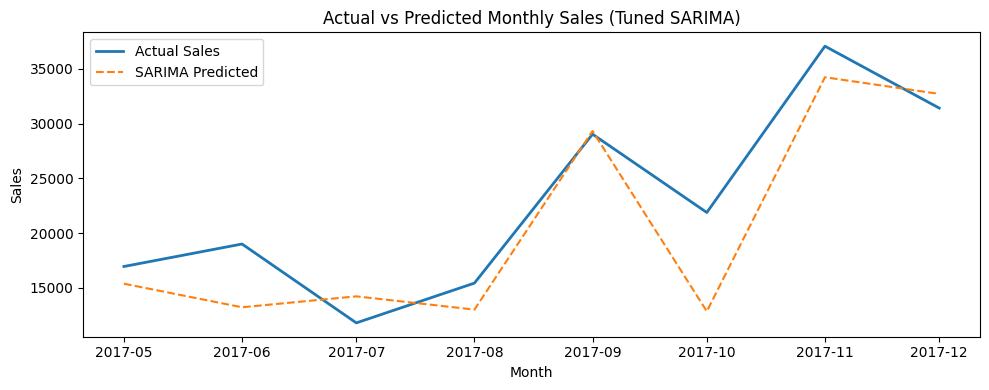

In [66]:
#SARIMA(tuned)-Actual vs predicted sales
test_sarima = test.copy()
test_sarima.index = pd.to_datetime(test_sarima.index)
plt.figure(figsize=(10, 4))
plt.plot(test_sarima.index, test_sarima['Sales'], label='Actual Sales', linewidth=2)
plt.plot(test_sarima.index, pred_tuned, label='SARIMA Predicted', linestyle='--')
plt.title("Actual vs Predicted Monthly Sales (Tuned SARIMA)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


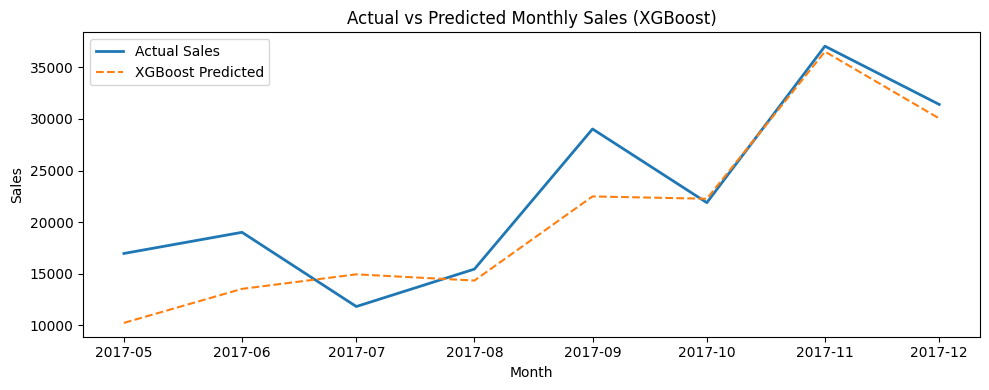

In [67]:
#XGBoost-Actual vs predicted
test_xgb = test.copy()
test_xgb.index = pd.to_datetime(test_xgb.index)
plt.figure(figsize=(10, 4))
plt.plot(test_xgb.index, test_xgb['Sales'], label='Actual Sales', linewidth=2)
plt.plot(test_xgb.index, xgb_pred, label='XGBoost Predicted', linestyle='--')
plt.title("Actual vs Predicted Monthly Sales (XGBoost)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


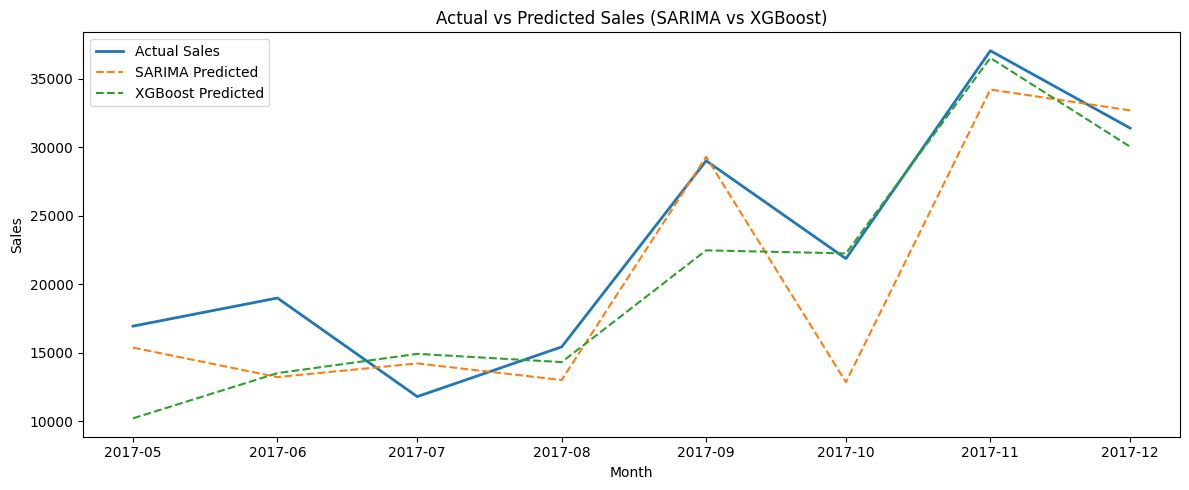

In [68]:
#combined comparison plot: Actual vs SARIMA vs XGBoost
plt.figure(figsize=(12, 5))
plt.plot(test_sarima.index, test_sarima['Sales'], label='Actual Sales', linewidth=2)
plt.plot(test_sarima.index, pred_tuned, label='SARIMA Predicted', linestyle='--')
plt.plot(test_sarima.index, xgb_pred, label='XGBoost Predicted', linestyle='--')
plt.title("Actual vs Predicted Sales (SARIMA vs XGBoost)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


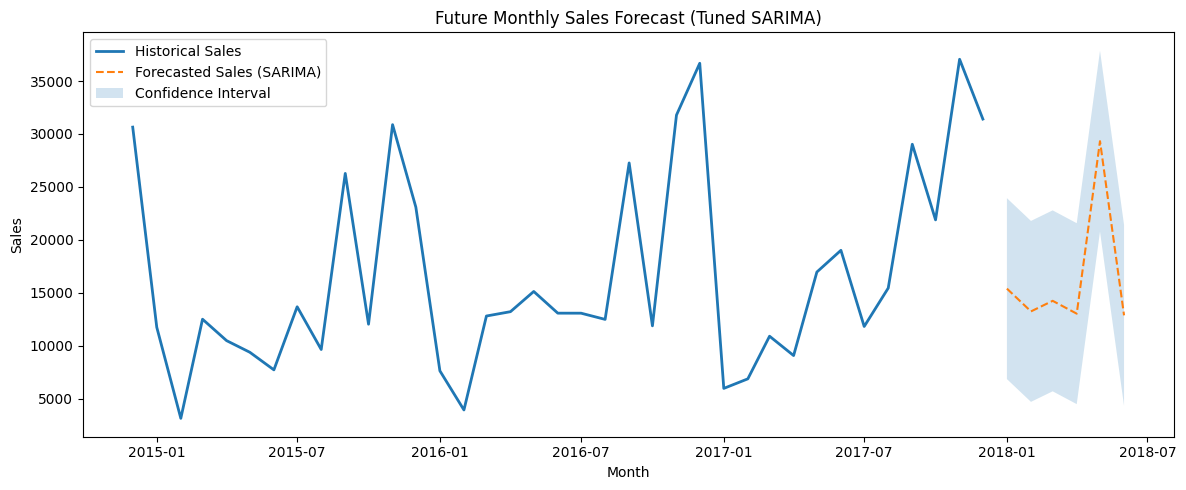

In [69]:
#future forecast with confidence intervals (SARIMA)
# Number of months to forecast
n_steps = 6

# Get future forecast from tuned SARIMA
sarima_forecast = sarima_tuned.get_forecast(steps=n_steps)
forecast_mean = sarima_forecast.predicted_mean
forecast_ci = sarima_forecast.conf_int()

# Build future index starting from last date in monthly_model
last_date = pd.to_datetime(monthly_model.index.max())
future_index = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=n_steps, freq='MS')

# Make sure index matches
forecast_mean.index = future_index
forecast_ci.index = future_index

# Plot historical + forecast with CI
history = monthly_model.copy()
history.index = pd.to_datetime(history.index)

plt.figure(figsize=(12, 5))
plt.plot(history.index, history['Sales'], label='Historical Sales', linewidth=2)

plt.plot(future_index, forecast_mean, label='Forecasted Sales (SARIMA)', linestyle='--')

# Confidence intervals as shaded band
plt.fill_between(
    future_index,
    forecast_ci.iloc[:, 0],  # lower bound
    forecast_ci.iloc[:, 1],  # upper bound
    alpha=0.2,
    label='Confidence Interval')

plt.title("Future Monthly Sales Forecast (Tuned SARIMA)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


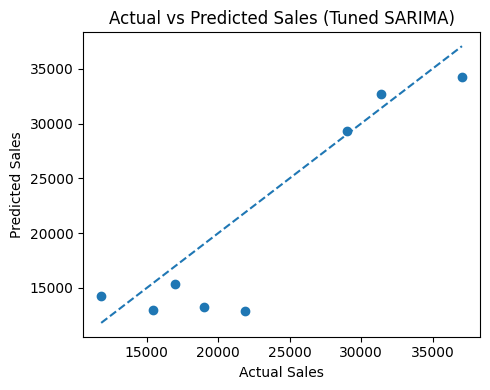

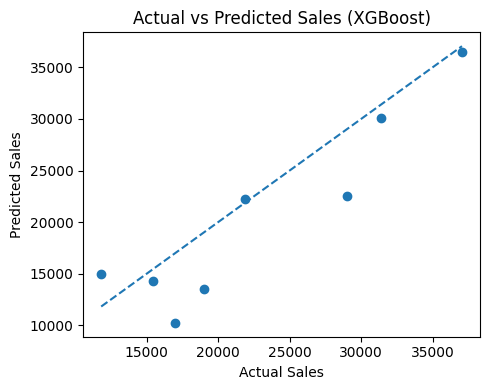

In [70]:

# SARIMA scatter
plt.figure(figsize=(5, 4))
plt.scatter(test_sarima['Sales'], pred_tuned)
plt.plot([test_sarima['Sales'].min(), test_sarima['Sales'].max()],
         [test_sarima['Sales'].min(), test_sarima['Sales'].max()],
         linestyle='--')
plt.title("Actual vs Predicted Sales (Tuned SARIMA)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

# XGBoost scatter
plt.figure(figsize=(5, 4))
plt.scatter(test_xgb['Sales'], xgb_pred)
plt.plot([test_xgb['Sales'].min(), test_xgb['Sales'].max()],
         [test_xgb['Sales'].min(), test_xgb['Sales'].max()],
         linestyle='--')
plt.title("Actual vs Predicted Sales (XGBoost)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()


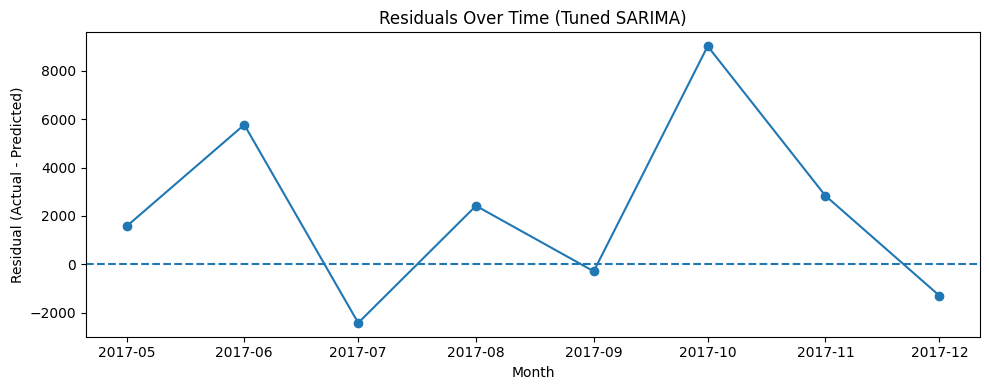

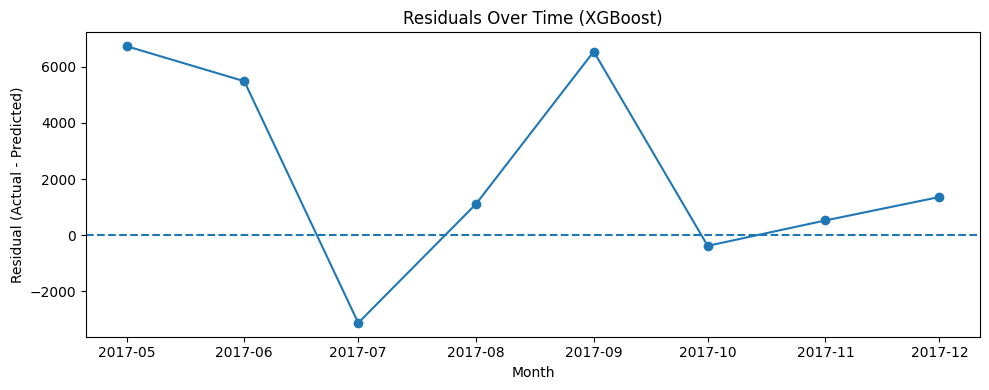

In [71]:
# Residuals for SARIMA
resid_sarima = test_sarima['Sales'] - pred_tuned

plt.figure(figsize=(10, 4))
plt.plot(test_sarima.index, resid_sarima, marker='o')
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (Tuned SARIMA)")
plt.xlabel("Month")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Residuals for XGBoost
resid_xgb = test_xgb['Sales'] - xgb_pred

plt.figure(figsize=(10, 4))
plt.plot(test_xgb.index, resid_xgb, marker='o')
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (XGBoost)")
plt.xlabel("Month")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


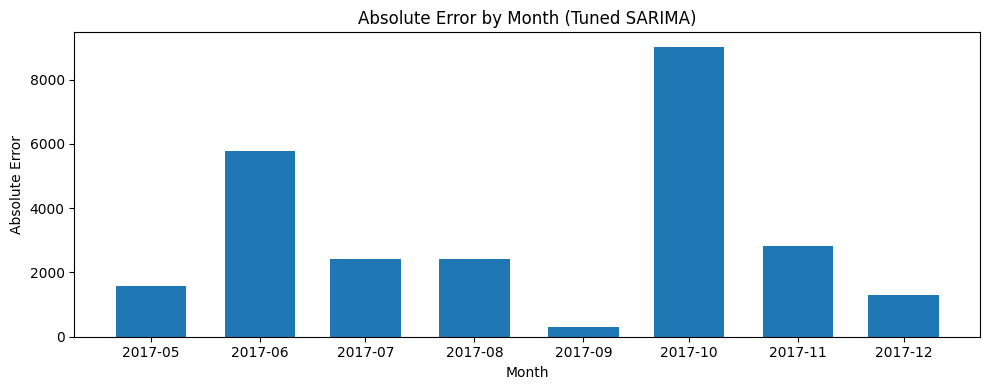

In [72]:
abs_error_sarima = resid_sarima.abs()

plt.figure(figsize=(10, 4))
plt.bar(test_sarima.index, abs_error_sarima, width=20)
plt.title("Absolute Error by Month (Tuned SARIMA)")
plt.xlabel("Month")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()


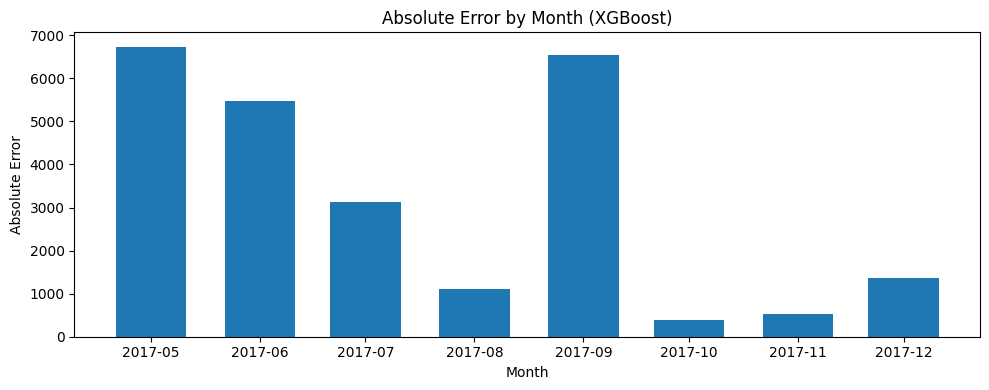

In [73]:
abs_error_xgb = resid_xgb.abs()

plt.figure(figsize=(10, 4))
plt.bar(test_xgb.index, abs_error_xgb, width=20)
plt.title("Absolute Error by Month (XGBoost)")
plt.xlabel("Month")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()
